
## Paso 1: Recolección de Data

Se scrapean dos fuentes de la ONPE:
1. **Votos por candidato** por región (presidenciales)
2. **Participación ciudadana** por región (electores hábiles, asistentes, ausentes)

> **Nota:** Las celdas de scraping requieren Selenium + Chrome. Si no están disponibles,
> se usarán los datos hardcodeados de respaldo más abajo.

In [ ]:
# =============================================================================
# CELDA 1A: Scraping de votos por candidato por región
# =============================================================================
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

URL_VOTOS = "https://resultadoelectoral.onpe.gob.pe/main/presidenciales"

REGIONES = [
    "AMAZONAS","ÁNCASH","APURÍMAC","AREQUIPA","AYACUCHO","CAJAMARCA",
    "CALLAO","CUSCO","HUANCAVELICA","HUÁNUCO","ICA","JUNÍN",
    "LA LIBERTAD","LAMBAYEQUE","LIMA","LORETO","MADRE DE DIOS",
    "MOQUEGUA","PASCO","PIURA","PUNO","SAN MARTÍN","TACNA", "TUMBES", "UCAYALI"
]
TODAS_UBICACIONES = REGIONES + ["EXTRANJERO"]


def parse_votes(text):
    digits = re.sub(r"[^\d]", "", text)
    return int(digits) if digits else 0


def extract_results(html):
    soup = BeautifulSoup(html, "lxml")
    results = {}
    articles = soup.select("article.candidato")
    for article in articles:
        text = article.get_text(" ", strip=True)
        name = None
        h3 = article.select_one("h3")
        if h3:
            name = h3.get_text(strip=True)
        if not name:
            if "VOTOS EN BLANCO" in text.upper():
                name = "VOTOS EN BLANCO"
            elif "VOTOS NULOS" in text.upper():
                name = "VOTOS NULOS"
        if not name:
            continue
        match = re.search(r"Cantidad de votos:\s*([0-9'.,]+)", text)
        if match:
            votes = parse_votes(match.group(1))
            results[name] = votes
    return results


def select_region(driver, wait, region_name):
    region = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, "mat-select[formcontrolname='department']"))
    )
    driver.execute_script("arguments[0].click();", region)
    time.sleep(3)
    option = wait.until(
        EC.element_to_be_clickable((
            By.XPATH,
            f"//mat-option[.//span[normalize-space()='{region_name}']]"
        ))
    )
    driver.execute_script("arguments[0].click();", option)


def select_ambito(driver, wait, value):
    ambito = wait.until(
        EC.element_to_be_clickable((By.XPATH, "(//mat-select)[1]"))
    )
    driver.execute_script("arguments[0].click();", ambito)
    option = wait.until(
        EC.element_to_be_clickable((
            By.XPATH,
            f"//mat-option[.//span[normalize-space()='{value}']]"
        ))
    )
    driver.execute_script("arguments[0].click();", option)


def scrape_votos():
    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--lang=es-PE")
    driver = None
    try:
        driver = webdriver.Chrome(options=options)
        wait = WebDriverWait(driver, 30)
        driver.get(URL_VOTOS)
        wait.until(lambda d: d.execute_script("return document.readyState") == "complete")
        wait.until(EC.presence_of_element_located((By.TAG_NAME, "app-root")))
        time.sleep(2)

        # --- Extraer % actas contabilizadas de la página inicial ---
        page_text = ' '.join(driver.page_source.split())
        match_actas = re.search(r'Actas contabilizadas\s*([0-9.,]+)\s*%', page_text, re.IGNORECASE)
        actas_pct = float(match_actas.group(1).replace(',', '.')) if match_actas else None
        print(f"[INFO] Actas contabilizadas: {actas_pct}%")

        select_ambito(driver, wait, "PERÚ")
        time.sleep(2)

        all_data = {}
        for region_name in REGIONES:
            select_region(driver, wait, region_name)
            time.sleep(1)
            all_data[region_name] = extract_results(driver.page_source)

        select_ambito(driver, wait, "EXTRANJERO")
        time.sleep(1)
        all_data["EXTRANJERO"] = extract_results(driver.page_source)

        # Build dataframe: rows=candidatos, cols=regiones
        candidatos = sorted(set(c for r in all_data.values() for c in r.keys()))
        rows = []
        for candidato in candidatos:
            row = {"Candidato": candidato}
            for ubicacion in TODAS_UBICACIONES:
                row[ubicacion] = all_data.get(ubicacion, {}).get(candidato, 0)
            rows.append(row)

        return pd.DataFrame(rows), actas_pct
    finally:
        if driver:
            driver.quit()


try:
    df_votos, pct_actas_contabilizadas = scrape_votos()
    print(f"[OK] Votos scrapeados: {df_votos.shape}")
    print(f"[OK] Actas contabilizadas: {pct_actas_contabilizadas}%")
    SCRAPING_OK_VOTOS = True
except Exception as e:
    print(f"[WARN] Scraping de votos falló: {e}")
    print("[INFO] Se usarán datos hardcodeados en la siguiente celda.")
    SCRAPING_OK_VOTOS = False

[INFO] Actas contabilizadas: None%
[OK] Votos scrapeados: (38, 27)
[OK] Actas contabilizadas: None%


In [40]:
print(df_votos.head())

                                  Candidato  AMAZONAS  ÁNCASH  APURÍMAC  \
0                    ALEX GONZALES CASTILLO       616    4307       912   
1       ALFONSO CARLOS ESPA Y GARCES-ALVEAR      2172   14303      3289   
2  ALVARO GONZALO PAZ DE LA BARRA FREIGEIRO       217    1069       356   
3                     ANTONIO ORTIZ VILLANO       237     770       573   
4           ARMANDO JOAQUIN MASSE FERNANDEZ       268     802       308   

   AREQUIPA  AYACUCHO  CAJAMARCA  CALLAO  CUSCO  HUANCAVELICA  ...  \
0      2891      1555       2452    1644   3068           840  ...   
1     39954      5567      10906   22332  19207          2521  ...   
2      1144       514        858     511   1157           323  ...   
3       828       563       1205     339   1221           294  ...   
4      1611       435       1008     392   1028           222  ...   

   MADRE DE DIOS  MOQUEGUA  PASCO  PIURA   PUNO  SAN MARTÍN  TACNA  TUMBES  \
0            359       393    563   3056   3369   

In [41]:
# =============================================================================
# CELDA 1B: Scraping de participación ciudadana por región
# =============================================================================

URL_PARTICIPACION = "https://resultadoelectoral.onpe.gob.pe/main/participacion-ciudadana"


def normalize_spaces(text):
    return " ".join((text or "").split()).strip()


def extract_participacion_data(html):
    soup = BeautifulSoup(html, "lxml")
    text = normalize_spaces(soup.get_text(" ", strip=True))

    data = {}
    for key, pattern in [
        ("electores_habiles", r"Electores hábiles\s*([0-9.,']+)"),
        ("total_asistentes", r"Total de asistentes\s*([0-9.,']+)"),
        ("total_ausentes", r"Total de ausentes\s*([0-9.,']+)"),
    ]:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        data[key] = parse_votes(match.group(1)) if match else None
    return data


def scrape_participacion():
    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--lang=es-PE")
    driver = None
    try:
        driver = webdriver.Chrome(options=options)
        wait = WebDriverWait(driver, 30)
        driver.get(URL_PARTICIPACION)
        wait.until(lambda d: d.execute_script("return document.readyState") == "complete")
        wait.until(EC.presence_of_element_located((By.TAG_NAME, "app-root")))
        time.sleep(1)

        select_ambito(driver, wait, "PERÚ")
        time.sleep(1)

        all_data = {}
        for region_name in REGIONES:
            select_region(driver, wait, region_name)
            time.sleep(1)
            data = extract_participacion_data(driver.page_source)
            if not all(v is not None for v in data.values()):
                raise RuntimeError(f"Datos incompletos para {region_name}: {data}")
            all_data[region_name] = data

        select_ambito(driver, wait, "EXTRANJERO")
        time.sleep(1)
        data = extract_participacion_data(driver.page_source)
        if not all(v is not None for v in data.values()):
            raise RuntimeError(f"Datos incompletos para EXTRANJERO: {data}")
        all_data["EXTRANJERO"] = data

        rows = []
        for ubicacion in TODAS_UBICACIONES:
            d = all_data[ubicacion]
            rows.append({
                "Ubicacion": ubicacion,
                "electores_habiles": d["electores_habiles"],
                "total_asistentes": d["total_asistentes"],
                "total_ausentes": d["total_ausentes"],
            })
        return pd.DataFrame(rows)
    finally:
        if driver:
            driver.quit()


try:
    df_participacion = scrape_participacion()
    print(f"[OK] Participación scrapeada: {df_participacion.shape}")
    SCRAPING_OK_PART = True
except Exception as e:
    print(f"[WARN] Scraping de participación falló: {e}")
    print("[INFO] Se usarán datos hardcodeados en la siguiente celda.")
    SCRAPING_OK_PART = False

[OK] Participación scrapeada: (26, 4)


## Paso 2: Procesamiento de Data

### Lógica contable fundamental
```
electores_habiles = total_asistentes + total_ausentes + votos_restantes
```
Donde `votos_restantes` son las actas aún no contabilizadas.

De esos `votos_restantes`, estimamos cuántos votarán (asistentes esperados) vs cuántos no
(ausentes esperados), usando la tasa de asistencia observada en las actas ya contadas.

### Identidad que debe cumplirse por región:
```
votos_reales + votos_esperados + ausentes_reales + ausentes_esperados = electores_habiles
```

### Identidad global:
```
Σ(electores_habiles) = 27,325,432
```

In [42]:
# =============================================================================
# CELDA 2: Procesamiento completo
# =============================================================================

# --- Validación de consistencia entre datasets ---
regiones_votos = sorted([c for c in df_votos.columns if c != "Candidato"])
regiones_part = sorted(list(df_participacion["Ubicacion"]))

if regiones_votos != regiones_part:
    missing_in_votos = set(regiones_part) - set(regiones_votos)
    missing_in_part = set(regiones_votos) - set(regiones_part)
    raise ValueError(
        f"Mismatch de regiones!\n"
        f"  En participación pero no en votos: {missing_in_votos}\n"
        f"  En votos pero no en participación: {missing_in_part}"
    )

UBICACIONES = regiones_votos  # lista canónica
print(f"[OK] {len(UBICACIONES)} ubicaciones consistentes entre datasets")

# --- Asegurar tipos numéricos en df_votos ---
for col in UBICACIONES:
    df_votos[col] = pd.to_numeric(df_votos[col], errors="coerce").fillna(0).astype(int)

# --- Asegurar tipos numéricos en df_participacion ---
for col in ["electores_habiles", "total_asistentes", "total_ausentes"]:
    df_participacion[col] = pd.to_numeric(df_participacion[col], errors="coerce").fillna(0).astype(int)

# --- Validar electores hábiles total ---
total_eh = df_participacion["electores_habiles"].sum()
print(f"Electores hábiles (suma regiones): {total_eh:,}")
print(f"Electores hábiles (esperado):      {ELECTORES_HABILES_TOTAL:,}")
if total_eh != ELECTORES_HABILES_TOTAL:
    print(f"[WARN] Diferencia de {total_eh - ELECTORES_HABILES_TOTAL:,} electores")

# --- Validar que votos reales por región <= asistentes por región ---
votos_por_region = df_votos[UBICACIONES].sum(axis=0)
for ubi in UBICACIONES:
    asistentes = df_participacion.loc[df_participacion["Ubicacion"] == ubi, "total_asistentes"].iloc[0]
    votos_region = votos_por_region[ubi]
    if votos_region > asistentes:
        print(f"[WARN] {ubi}: votos ({votos_region:,}) > asistentes ({asistentes:,})")

# =============================================================================
# CÁLCULOS DE PARTICIPACIÓN
# =============================================================================

# Actas no contabilizadas aún
df_participacion["votos_restantes"] = (
    df_participacion["electores_habiles"]
    - df_participacion["total_asistentes"]
    - df_participacion["total_ausentes"]
)

# Tasa de asistencia observada
denominador = df_participacion["total_asistentes"] + df_participacion["total_ausentes"]
df_participacion["tasa_asistencia"] = np.where(
    denominador > 0,
    df_participacion["total_asistentes"] / denominador,
    0.0
)

# Estimar asistentes y ausentes esperados de los restantes
# Usamos round (no ceil) para que la suma sea consistente
df_participacion["restantes_asistentes_raw"] = (
    df_participacion["tasa_asistencia"] * df_participacion["votos_restantes"]
)
df_participacion["restantes_asistentes"] = df_participacion["restantes_asistentes_raw"].round(0).astype(int)

# Ausentes esperados = restantes - asistentes esperados (por diferencia, no por cálculo independiente)
# Esto garantiza: restantes_asistentes + restantes_ausentes = votos_restantes EXACTAMENTE
df_participacion["restantes_ausentes"] = (
    df_participacion["votos_restantes"] - df_participacion["restantes_asistentes"]
)

# --- Verificación de identidad por región ---
print("\n--- Verificación de identidad contable por región ---")
errores = 0
for _, row in df_participacion.iterrows():
    total_check = (
        row["total_asistentes"]
        + row["total_ausentes"]
        + row["restantes_asistentes"]
        + row["restantes_ausentes"]
    )
    if total_check != row["electores_habiles"]:
        print(f"[ERROR] {row['Ubicacion']}: suma={total_check:,} != EH={row['electores_habiles']:,}")
        errores += 1

if errores == 0:
    print("[OK] Identidad contable verificada para todas las regiones")

# --- Verificación global ---
total_asistentes_real = df_participacion["total_asistentes"].sum()
total_ausentes_real = df_participacion["total_ausentes"].sum()
total_rest_asist = df_participacion["restantes_asistentes"].sum()
total_rest_ausent = df_participacion["restantes_ausentes"].sum()
gran_total = total_asistentes_real + total_ausentes_real + total_rest_asist + total_rest_ausent

print(f"\n--- Totales globales ---")
print(f"Asistentes reales:    {total_asistentes_real:>12,}")
print(f"Ausentes reales:      {total_ausentes_real:>12,}")
print(f"Asistentes esperados: {total_rest_asist:>12,}")
print(f"Ausentes esperados:   {total_rest_ausent:>12,}")
print(f"TOTAL:                {gran_total:>12,}")
print(f"Electores hábiles:    {total_eh:>12,}")
assert gran_total == total_eh, f"Error global: {gran_total} != {total_eh}"
print("[OK] Identidad global verificada")

# =============================================================================
# POPULARIDAD (proporción de votos por candidato por región)
# =============================================================================

# Calcular popularidad: votos_candidato / total_votos_region
df_popularidad = df_votos.copy()
for col in UBICACIONES:
    total = df_votos[col].sum()
    if total > 0:
        df_popularidad[col] = df_votos[col] / total
    else:
        # Si no hay votos, distribución uniforme
        n = len(df_votos)
        df_popularidad[col] = 1.0 / n

# Verificar que las proporciones sumen 1 por región
for col in UBICACIONES:
    s = df_popularidad[col].sum()
    if abs(s - 1.0) > 1e-6:
        print(f"[WARN] Popularidad en {col} suma {s:.8f}, no 1.0")

# =============================================================================
# VOTOS ESPERADOS RESTANTES (estimación puntual)
# =============================================================================

restantes_map = dict(zip(df_participacion["Ubicacion"], df_participacion["restantes_asistentes"]))

df_votos_esperados = df_votos[["Candidato"]].copy()
for col in UBICACIONES:
    n_restantes = restantes_map[col]
    # Votos esperados = popularidad * restantes_asistentes
    df_votos_esperados[col] = df_popularidad[col] * n_restantes

# =============================================================================
# RESULTADO ESPERADO TOTAL (votos reales + votos esperados)
# =============================================================================

EXCLUIR = {"VOTOS EN BLANCO", "VOTOS NULOS"}

# Total por candidato
votos_reales_total = df_votos.set_index("Candidato")[UBICACIONES].sum(axis=1)
votos_esperados_total = df_votos_esperados.set_index("Candidato")[UBICACIONES].sum(axis=1)

df_resultado = pd.DataFrame({
    "Candidato": votos_reales_total.index,
    "Votos Reales": votos_reales_total.values.astype(int),
    "Votos Esperados": votos_esperados_total.values.round(0).astype(int),
})
df_resultado["Total Esperado"] = df_resultado["Votos Reales"] + df_resultado["Votos Esperados"]
df_resultado = df_resultado.sort_values("Total Esperado", ascending=False).reset_index(drop=True)

print("\n--- Resultado esperado (top 10) ---")
print(df_resultado.head(10).to_string(index=False))

# --- Verificación: votos esperados totales deben ≈ restantes_asistentes totales ---
print(f"\nSuma votos esperados: {df_resultado['Votos Esperados'].sum():,}")
print(f"Restantes asistentes: {total_rest_asist:,}")

print("\n[OK] Procesamiento completado")

[OK] 26 ubicaciones consistentes entre datasets
Electores hábiles (suma regiones): 27,325,432
Electores hábiles (esperado):      27,325,432

--- Verificación de identidad contable por región ---
[OK] Identidad contable verificada para todas las regiones

--- Totales globales ---
Asistentes reales:      18,787,152
Ausentes reales:         6,424,247
Asistentes esperados:    1,387,958
Ausentes esperados:        726,075
TOTAL:                  27,325,432
Electores hábiles:      27,325,432
[OK] Identidad global verificada

--- Resultado esperado (top 10) ---
                           Candidato  Votos Reales  Votos Esperados  Total Esperado
        KEIKO SOFIA FUJIMORI HIGUCHI       2672267           206858         2879125
                     VOTOS EN BLANCO       2181090           180316         2361406
RAFAEL BERNARDO LÓPEZ ALIAGA CAZORLA       1866410           142572         2008982
    ROBERTO HELBERT SANCHEZ PALOMINO       1878342           128595         2006937
              JORGE 

## Paso 3: Simulación Monte Carlo

Para cada simulación:
1. Se toma la popularidad observada por región como parámetros de una distribución Dirichlet
2. Se genera una distribución de probabilidad aleatoria (perturbada) por región
3. Se distribuyen los `restantes_asistentes` de esa región usando Multinomial
4. Se suman a los votos reales

Esto genera 10,000 escenarios posibles que respetan la incertidumbre estadística.

In [43]:
# =============================================================================
# CELDA 3: Simulación Monte Carlo
# =============================================================================

N_SIMULACIONES = 10_000
DIRICHLET_STRENGTH = 500

print(f"Simulaciones: {N_SIMULACIONES:,}")
print(f"Dirichlet strength: {DIRICHLET_STRENGTH}")

# Preparar matrices
candidatos_lista = list(df_votos["Candidato"])
n_candidatos = len(candidatos_lista)
candidatos_solo = [c for c in candidatos_lista if c.upper() not in EXCLUIR]

# Votos reales como vector (suma de todas las regiones)
actual_vector = df_votos.set_index("Candidato")[UBICACIONES].sum(axis=1).reindex(candidatos_lista).values.astype(np.int64)

# Popularidad como matriz: (n_candidatos, n_ubicaciones)
pop_matrix = df_popularidad.set_index("Candidato")[UBICACIONES].reindex(candidatos_lista)

# Vector de restantes por región
restantes_vector = np.array([restantes_map[u] for u in UBICACIONES], dtype=np.int64)

print(f"Candidatos totales (incl. blanco/nulo): {n_candidatos}")
print(f"Candidatos para ranking: {len(candidatos_solo)}")
print(f"Ubicaciones: {len(UBICACIONES)}")
print(f"Total votos a simular: {restantes_vector.sum():,}")

# --- Simulación ---
sim_totales = np.zeros((N_SIMULACIONES, n_candidatos), dtype=np.int64)

for sim in range(N_SIMULACIONES):
    total_sim = actual_vector.copy()

    for j, region in enumerate(UBICACIONES):
        n_restantes = int(restantes_vector[j])
        if n_restantes <= 0:
            continue

        base_probs = pop_matrix[region].values.astype(float)
        prob_sum = base_probs.sum()
        if prob_sum <= 0:
            continue
        base_probs = base_probs / prob_sum  # re-normalizar por seguridad

        alpha = np.maximum(base_probs * DIRICHLET_STRENGTH, 1e-9)
        sampled_probs = np.random.dirichlet(alpha)
        sampled_votes = np.random.multinomial(n_restantes, sampled_probs)
        total_sim += sampled_votes

    sim_totales[sim, :] = total_sim

    if (sim + 1) % 2000 == 0:
        print(f"  Simulaciones: {sim + 1:,}/{N_SIMULACIONES:,}")

print(f"[OK] Monte Carlo completado: {N_SIMULACIONES:,} simulaciones")

# Convertir a DataFrame
sim_df = pd.DataFrame(sim_totales, columns=candidatos_lista)
sim_df_candidatos = sim_df[candidatos_solo].copy()

Simulaciones: 10,000
Dirichlet strength: 500
Candidatos totales (incl. blanco/nulo): 38
Candidatos para ranking: 36
Ubicaciones: 26
Total votos a simular: 1,387,958
  Simulaciones: 2,000/10,000
  Simulaciones: 4,000/10,000
  Simulaciones: 6,000/10,000
  Simulaciones: 8,000/10,000
  Simulaciones: 10,000/10,000
[OK] Monte Carlo completado: 10,000 simulaciones


## Paso 4: Resultados

Análisis de las simulaciones Monte Carlo:
- Ranking de candidatos con probabilidades de quedar en top 1, 2, 3
- Visualización de los top 5 candidatos esperados
- Probabilidades de escenarios entre 2do y 3er lugar

=== RANKING REAL ACTUAL (solo candidatos) ===
  1. KEIKO SOFIA FUJIMORI HIGUCHI: 2.672.267
  2. ROBERTO HELBERT SANCHEZ PALOMINO: 1.878.342
  3. RAFAEL BERNARDO LÓPEZ ALIAGA CAZORLA: 1.866.410
  4. JORGE NIETO MONTESINOS: 1.734.942
  5. RICARDO PABLO BELMONT CASSINELLI: 1.590.998

=== TOP 10 MONTE CARLO ===
                           Candidato  Promedio  DesvStd      P5     P50     P95  P(Top 1)  P(Top 2)  P(Top 3)
        KEIKO SOFIA FUJIMORI HIGUCHI   2879098     7245 2867416 2878967 2891222       1.0      1.00       1.0
RAFAEL BERNARDO LÓPEZ ALIAGA CAZORLA   2008915     7245 1997179 2008848 2020860       0.0      0.59       1.0
    ROBERTO HELBERT SANCHEZ PALOMINO   2006938     4277 2000095 2006786 2014144       0.0      0.41       1.0
              JORGE NIETO MONTESINOS   1850838     6491 1840497 1850684 1861727       0.0      0.00       0.0
    RICARDO PABLO BELMONT CASSINELLI   1702752     5602 1693844 1702563 1712198       0.0      0.00       0.0
       CARLOS GONSALO ALVAREZ L

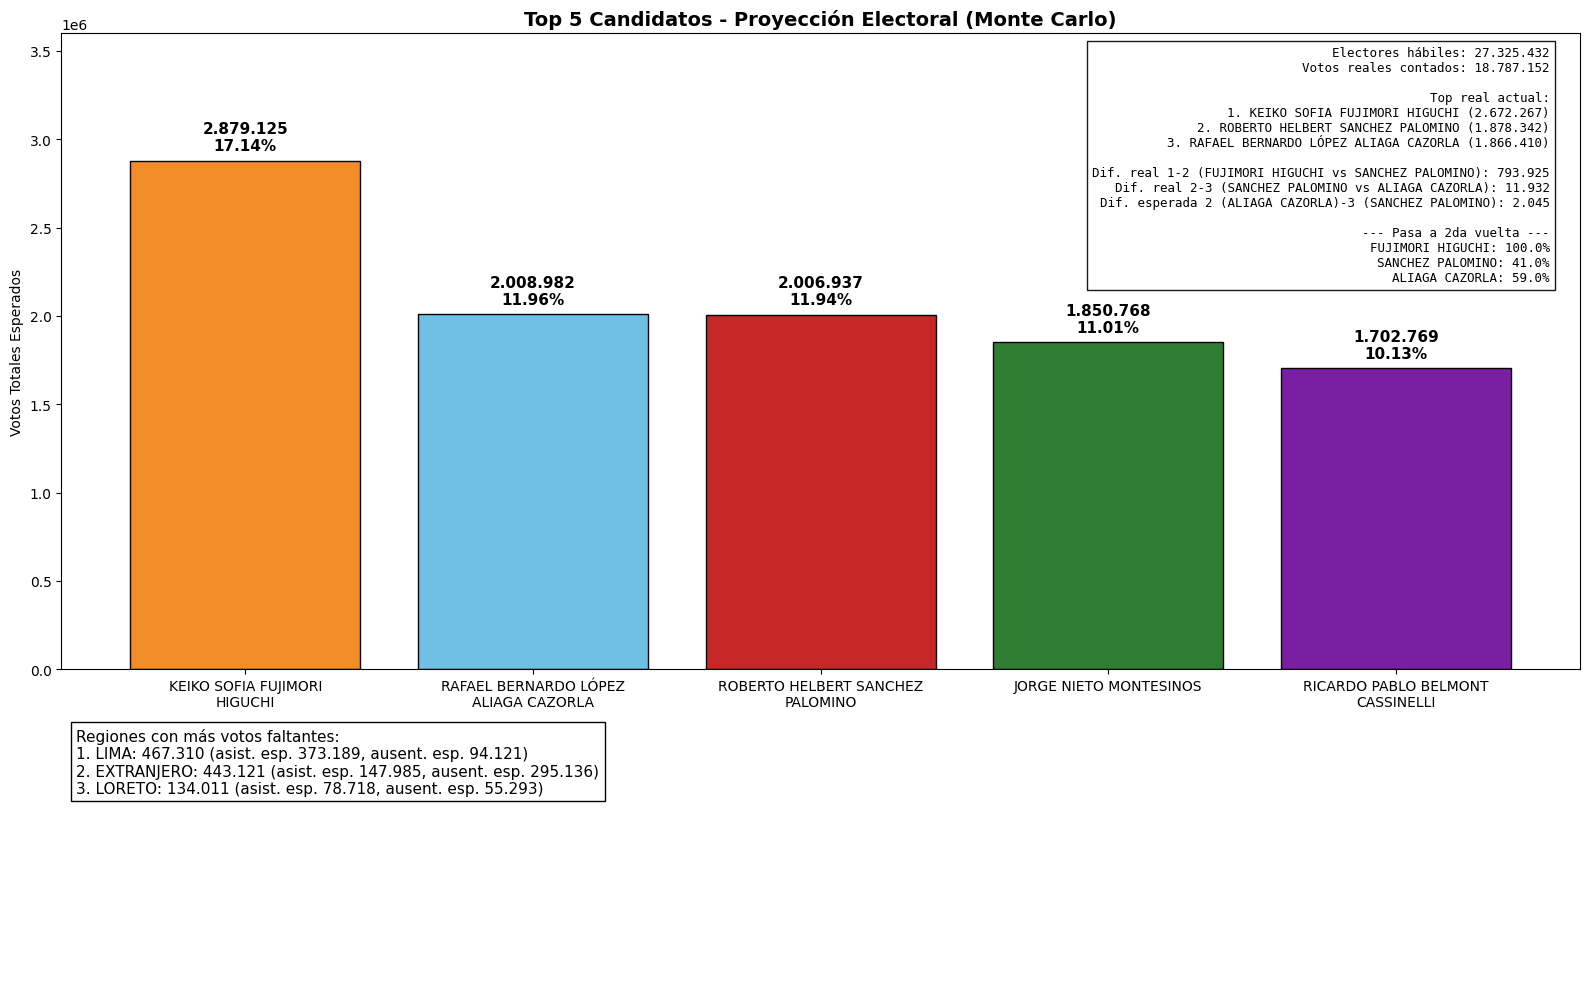


[OK] Gráfico guardado: top5_candidatos_esperados.png

=== VERIFICACIÓN FINAL ===
Electores hábiles:                      27,325,432
Votos reales (contados):                18,787,152
Ausentes reales:                         6,424,247
Votos esperados (restantes asist.):      1,387,958
Ausentes esperados (restantes ausent.):      726,075
SUMA TOTAL:                             27,325,432
Coincide con EH: SÍ ✓


In [44]:
# =============================================================================
# CELDA 4: Análisis y visualización de resultados
# =============================================================================
import matplotlib.pyplot as plt
import textwrap
from datetime import datetime

fecha = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def fmt_int(x):
    return f"{int(round(x)):,}".replace(",", ".")


def wrap_label(text, width=24):
    return "\n".join(textwrap.wrap(text, width=width))


# --- Ranking real actual ---
ranking_real = (
    pd.Series(actual_vector, index=candidatos_lista)
    .loc[candidatos_solo]
    .sort_values(ascending=False)
)
top1_name = ranking_real.index[0]
top2_name = ranking_real.index[1]
top3_name = ranking_real.index[2]

print("=== RANKING REAL ACTUAL (solo candidatos) ===")
for i, (name, votes) in enumerate(ranking_real.head(5).items()):
    print(f"  {i+1}. {name}: {fmt_int(votes)}")

# --- Estadísticas Monte Carlo ---
ranks_candidatos = sim_df_candidatos.rank(axis=1, ascending=False, method="min")

resumen_mc = pd.DataFrame({
    "Candidato": candidatos_solo,
    "Promedio": sim_df_candidatos.mean(axis=0).values.round(0).astype(int),
    "DesvStd": sim_df_candidatos.std(axis=0).values.round(0).astype(int),
    "P5": np.percentile(sim_df_candidatos.values, 5, axis=0).round(0).astype(int),
    "P50": np.percentile(sim_df_candidatos.values, 50, axis=0).round(0).astype(int),
    "P95": np.percentile(sim_df_candidatos.values, 95, axis=0).round(0).astype(int),
    "P(Top 1)": [(ranks_candidatos[c] == 1).mean() for c in candidatos_solo],
    "P(Top 2)": [(ranks_candidatos[c] <= 2).mean() for c in candidatos_solo],
    "P(Top 3)": [(ranks_candidatos[c] <= 3).mean() for c in candidatos_solo],
})
resumen_mc = resumen_mc.sort_values("Promedio", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 MONTE CARLO ===")
print(resumen_mc.head(10).to_string(index=False))

# --- Extraer P(Top 2) = P(pasa a segunda vuelta) para los top 3 ---
def get_p_top2(nombre):
    row = resumen_mc.loc[resumen_mc["Candidato"] == nombre]
    return row["P(Top 2)"].iloc[0] if len(row) > 0 else 0.0

p_top2_1 = get_p_top2(top1_name)
p_top2_2 = get_p_top2(top2_name)
p_top2_3 = get_p_top2(top3_name)

print(f"\n=== SEGUNDA VUELTA - ¿Quién pasa? ===")
print(f"  {top1_name}")
print(f"    P(Top 2) = {p_top2_1:.1%}")
print(f"  {top2_name}")
print(f"    P(Top 2) = {p_top2_2:.1%}")
print(f"  {top3_name}")
print(f"    P(Top 2) = {p_top2_3:.1%}")

# Diferencia esperada entre 2do y 3ro
diffs = sim_df_candidatos[top2_name] - sim_df_candidatos[top3_name]
print(f"\n  Dif. promedio 2do-3ro: {fmt_int(diffs.mean())}")
print(f"  Dif. P5-P95: [{fmt_int(np.percentile(diffs, 5))}, {fmt_int(np.percentile(diffs, 95))}]")

# =============================================================================
# GRÁFICO
# =============================================================================

COLOR_MAP = {
    "KEIKO SOFIA FUJIMORI HIGUCHI": "#f28c28",
    "RAFAEL BERNARDO LÓPEZ ALIAGA CAZORLA": "#6ec1e4",
    "ROBERTO HELBERT SANCHEZ PALOMINO": "#c62828",
    "JORGE NIETO MONTESINOS": "#2e7d32",
    "RICARDO PABLO BELMONT CASSINELLI": "#7b1fa2",
}
DEFAULT_COLOR = "#4e79a7"

# Top 5 esperados para el gráfico de barras
top5_resultado = df_resultado[~df_resultado["Candidato"].str.upper().isin(EXCLUIR)].head(5).copy()

# Porcentaje sobre votos válidos esperados
total_validos_esperado = df_resultado.loc[
    ~df_resultado["Candidato"].str.upper().isin(EXCLUIR), "Total Esperado"
].sum()

top5_resultado["Porcentaje"] = top5_resultado["Total Esperado"] / total_validos_esperado * 100
top5_resultado["Color"] = top5_resultado["Candidato"].map(COLOR_MAP).fillna(DEFAULT_COLOR)
top5_resultado["Etiqueta"] = top5_resultado["Candidato"].apply(wrap_label)

# Diferencias
diff_esp_2_3 = abs(
    top5_resultado.iloc[1]["Total Esperado"] - top5_resultado.iloc[2]["Total Esperado"]
)

real_v1 = ranking_real.iloc[0]
real_v2 = ranking_real.iloc[1]
real_v3 = ranking_real.iloc[2]
diff_real_1_2 = abs(real_v1 - real_v2)
diff_real_2_3 = abs(real_v2 - real_v3)
total_votos_reales = df_votos[UBICACIONES].sum().sum()

# Regiones con más faltantes
df_participacion["total_faltantes"] = df_participacion["restantes_asistentes"] + df_participacion["restantes_ausentes"]
top3_falt = df_participacion.nlargest(3, "total_faltantes")

regiones_txt = "\n".join([
    f"{i+1}. {r.Ubicacion}: {fmt_int(r.total_faltantes)} "
    f"(asist. esp. {fmt_int(r.restantes_asistentes)}, "
    f"ausent. esp. {fmt_int(r.restantes_ausentes)})"
    for i, (_, r) in enumerate(top3_falt.iterrows())
])

# Nombres cortos para el cuadro de texto
def short_name(name, max_len=22):
    parts = name.split()
    # Intentar apellido + primer nombre
    if len(parts) >= 3:
        short = f"{parts[-2]} {parts[-1]}"
        if len(short) <= max_len:
            return short
    return name[:max_len]

# --- PLOT ---
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[4, 1.3])
ax = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

bars = ax.bar(
    top5_resultado["Etiqueta"],
    top5_resultado["Total Esperado"],
    color=top5_resultado["Color"],
    edgecolor="black"
)

max_y = top5_resultado["Total Esperado"].max()
ax.set_ylim(0, max_y * 1.25)
ax.set_ylabel("Votos Totales Esperados")
ax.set_title("Top 5 Candidatos - Proyección Electoral (Monte Carlo)", fontsize=14, weight="bold")

for bar, (_, row) in zip(bars, top5_resultado.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_y * 0.02,
        f"{fmt_int(row['Total Esperado'])}\n{row['Porcentaje']:.2f}%",
        ha="center", fontsize=11, weight="bold"
    )

resumen_txt = (
    f"Electores hábiles: {fmt_int(total_eh)}\n"
    f"Votos reales contados: {fmt_int(total_votos_reales)}\n\n"
    f"Top real actual:\n"
    f"1. {top1_name} ({fmt_int(real_v1)})\n"
    f"2. {top2_name} ({fmt_int(real_v2)})\n"
    f"3. {top3_name} ({fmt_int(real_v3)})\n\n"
    f"Dif. real 1-2 ({short_name(top1_name)} vs {short_name(top2_name)}): {fmt_int(diff_real_1_2)}\n"
    f"Dif. real 2-3 ({short_name(top2_name)} vs {short_name(top3_name)}): {fmt_int(diff_real_2_3)}\n"
    f"Dif. esperada 2 (ALIAGA CAZORLA)-3 (SANCHEZ PALOMINO): {fmt_int(diff_esp_2_3)}\n\n"
    f"--- Pasa a 2da vuelta ---\n"
    f"{short_name(top1_name)}: {p_top2_1:.1%}\n"
    f"{short_name(top2_name)}: {p_top2_2:.1%}\n"
    f"{short_name(top3_name)}: {p_top2_3:.1%}"
)

ax.text(
    0.98, 0.98, resumen_txt,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9),
    family="monospace"
)

ax2.text(
    0.01, 0.9,
    "Regiones con más votos faltantes:\n" + regiones_txt,
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.savefig("top5_candidatos_esperados.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n[OK] Gráfico guardado: top5_candidatos_esperados.png")
print(f"\n=== VERIFICACIÓN FINAL ===")
print(f"Electores hábiles:                    {total_eh:>12,}")
print(f"Votos reales (contados):              {total_votos_reales:>12,}")
print(f"Ausentes reales:                      {total_ausentes_real:>12,}")
print(f"Votos esperados (restantes asist.):   {total_rest_asist:>12,}")
print(f"Ausentes esperados (restantes ausent.): {total_rest_ausent:>12,}")
total_final = total_votos_reales + total_ausentes_real + total_rest_asist + total_rest_ausent
print(f"SUMA TOTAL:                           {total_final:>12,}")
print(f"Coincide con EH: {'SÍ ✓' if total_final == total_eh else 'NO ✗'}")

In [1]:
print(df_participacion[['Ubicacion', 'electores_habiles']].to_string(index=False))
print(f"\nTotal: {df_participacion['electores_habiles'].sum():,}")

NameError: name 'df_participacion' is not defined